Problem 2: Random Forest Ensemble

In [23]:
import pandas as pd
from matplotlib import pyplot
from sklearn.ensemble import RandomForestClassifier
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, log_loss

In [14]:
# import fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
#print(spambase.metadata) 
  
# variable information 
#print(spambase.variables) 


1. Use an existing package to train a Random Forest ensemble with 10, 50, 100, and 500 decision trees on the SPAMBASE dataset. Report
accuracy, F1 score, and AUC on both the training and testing sets for $T \in \{10, 50, 100, 500\}$. How do the metrics change as $T$
increases?

In [15]:
# split data into training and test sets:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

trees = [10, 50, 100, 500]
rows = []

for t in trees:
    rf = RandomForestClassifier(n_estimators=t)
    rf.fit(X_train, y_train)

    for train_or_test, x, y_true in [("Train", X_train, y_train),
                                  ("Test",  X_test,  y_test)]:
        
        y_pred = rf.predict(x)

        rows.append({
            "Train or Test": train_or_test,
            "Trees": t,
            "Train or Test": train_or_test,
            "Accuracy": accuracy_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred),
            "AUC": roc_auc_score(y_true, y_pred)
        })
    
pd.DataFrame(rows).set_index("Train or Test")

/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/pavithra/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. P

,Trees,Accuracy,F1,AUC
Train or Test,,,,
Train,10,0.995380,0.994004,0.994416
Test,10,0.947883,0.936675,0.942887
Train,50,0.998913,0.998595,0.998854
Test,50,0.954397,0.944737,0.949899
Train,100,0.999457,0.999297,0.999427
Test,100,0.953312,0.943347,0.948617
Train,500,0.999457,0.999297,0.999427
Test,500,0.957655,0.948752,0.953404


2. Compare the metrics obtained for Random Forest with the Decision tree metrics obtained in Problem 1. Write down some observations.

observations...

3. Compute the variable importance for each feature and include a plot.

Feature: 0, Score: 0.00374
Feature: 1, Score: 0.00561
Feature: 2, Score: 0.01018
Feature: 3, Score: 0.00108
Feature: 4, Score: 0.03049
Feature: 5, Score: 0.00633
Feature: 6, Score: 0.08236
Feature: 7, Score: 0.01345
Feature: 8, Score: 0.00478
Feature: 9, Score: 0.00696
Feature: 10, Score: 0.00901
Feature: 11, Score: 0.01171
Feature: 12, Score: 0.00311
Feature: 13, Score: 0.00209
Feature: 14, Score: 0.00140
Feature: 15, Score: 0.06883
Feature: 16, Score: 0.01569
Feature: 17, Score: 0.00825
Feature: 18, Score: 0.02838
Feature: 19, Score: 0.00599
Feature: 20, Score: 0.05288
Feature: 21, Score: 0.00211
Feature: 22, Score: 0.02445
Feature: 23, Score: 0.03229
Feature: 24, Score: 0.04220
Feature: 25, Score: 0.01517
Feature: 26, Score: 0.02221
Feature: 27, Score: 0.00544
Feature: 28, Score: 0.00193
Feature: 29, Score: 0.00418
Feature: 30, Score: 0.00184
Feature: 31, Score: 0.00073
Feature: 32, Score: 0.00301
Feature: 33, Score: 0.00056
Feature: 34, Score: 0.00346
Feature: 35, Score: 0.00383
Fe

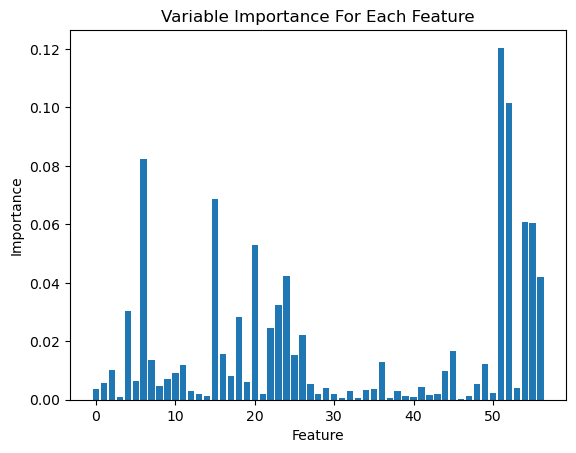

In [22]:
importances = rf.feature_importances_

# summarize feature importance
for feature,score in enumerate(importances):
	print('Feature: %0d, Score: %.5f' % (feature,score))
# plot feature importance
pyplot.bar([x for x in range(len(importances))], importances)
pyplot.xlabel("Feature")
pyplot.ylabel("Importance")
pyplot.title("Variable Importance For Each Feature")
pyplot.show()